## 0. Purpose

This script converts the data into pd.dataframes which can be used to train the RF. Using the settings, over- and undersampling can be used to create a balanced dataset. The trained regions can also be chosen.

## 1. Import Packages


In [191]:
#%pip install xarray rioxarray pandas matplotlib rasterio
import geopandas as gpd
import xarray as xr
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import rioxarray
from rasterio import rio
from rasterio import features
from rasterio.enums import Resampling
import numpy as np
from rasterio.transform import Affine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tornado.gen import multi

## 2. Convert Trainingdata to dataframe

### 2.1 Settings

These settings allow to quickly change the inputs for the Random forest.

### chosen_bands:

Here you can change the input bands, indices and texture variables.

### REGION_TRAIN_MODE

Here you can change the data used for training the random forest classifier.\
N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
This input solely changes the training data.

### REGION_VAL_MODE

Here you can change the data used for validating the random forest classifer.\
If REGION_TRAIN_MODE equals REGION_VAL_MODE, a training/validation split of 70/30 is used.\
If all the data is used to train the model (REGION_TRAIN_MODE == ALL) and is used on one scene (e.g. N22), half of the N22 data is used for validation, half of the data is used for training. The option ALL for REGION_VAL_MODE is only provided if REGION_TRAIN_MODE is ALL as well.

### BALANCE_MODE

UNDERSAMPLING: undersamples the majority classes so that all classes have the same number of pixels/rows in the training data.\
OVERSAMPLING: oversamples the minority class.\
WEIGHTS: upsamples only "deadwood" class by a certain factor.

### (OVERSAMPLE_NUMBER)

Only usable if BALANCE_MODE = OVERSAMPLING.\
OVERSAMPLE_NUMBER: the number to which the minority class is oversampled.\
The number of all valid pixels of all classes used with OVERSAMPLING is therefore 3*OVERSAMPLE_NUMBER.

### VAL_BALANCE

VAL_BALANCE decides how the validation/test-data is treated.\
NONE: unbalanced training data is used\
WEIGHTS: You can give the minority class "deadwood" a weight, and only this class will be oversampled.\
SAME: The validation data gets the same treatment as the training data, and is therefore balanced.


### PREDICTION_MODE
value: The random forests predicts a specific value, in this case, a class (1, 2 or 3).\
proba: The random forests predicts a probabilty for each class. This option can be used to make it "harder" for the model to predict the deadwood class.


### (PROBA_THRESHOLD)

PROBA_THRESHOLD: only useable if you used PREDICTION_MODE = proba.\
The threshold the deadwood class needs to reach to be classified.\
If the PROBA_THRESHOLD is 0.8, 80% of the decision trees have to predict "deadwood", for the pixel to get classified as "deadwood".

### FIT

if FIT == "balanced"; the scit-learn option of class_weights = balanced_subsamples is used.\
Every other input just uses the default random forest.

### (WEIGHT_MUTLIPLIER)

If BALANCE_MODE == WEIGHTS, than this is the multiplier used on the deadwood class.

In [192]:
chosen_bands = ["blue", "green", "red", "rededge1", "rededge3", "nir", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
REGION_TRAIN_MODE = "ALL"
REGION_VAL_MODE = "ALL"
BALANCE_MODE = "NONE"
VAL_BALANCE = "NONE"
FIT = "x"
OVERSAMPLE_NUMBER = 3500
PREDICTION_MODE = "proba" # options: "value" , "proba"
PROBA_THRESHOLD = 0.8
WEIGHT_MULTIPLIER = 6

### 2.2 Importing Data

This code block opens the required data, removes NAs and converts it to a pd_datframe.

In [193]:
def open_with_labels(path): # small helper function, so the band labels dont get deleted during rioxarray.open_rasterio()
    da = rioxarray.open_rasterio(path)
    if 'long_name' in da.attrs:
        da = da.assign_coords(band=list(da.attrs['long_name']))
    return da

#########################
# TRAIN WITH SINGLE DATE
#########################

if REGION_TRAIN_MODE == "N22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "N23":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster = raster.drop_sel(band = "std")
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

if REGION_TRAIN_MODE == "S20":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "S22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

##############################
# TRAIN WITH ALL; VAL WITH ALL
##############################

if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE == "ALL":

        raster1 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster1 = raster1.drop_sel(band = "std") # not useful and NA most of the time
        raster2 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster2 = raster2.drop_sel(band = "std") # not useful and NA most of the time
        raster3 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster3 = raster3.drop_sel(band = "std") # not useful and NA most of the time
        raster4 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster4 = raster4.drop_sel(band = "std") # not useful and NA most of the time

        r1_flat = raster1.stack(samples=("y", "x")).dropna("samples")
        r2_flat = raster2.stack(samples=("y", "x")).dropna("samples")
        r3_flat = raster3.stack(samples=("y", "x")).dropna("samples")
        r4_flat = raster4.stack(samples=("y", "x")).dropna("samples")

        raster = xr.concat([r1_flat, r2_flat, r3_flat, r4_flat], dim='samples')
        df = raster.to_pandas().T.dropna()
        df = df.reset_index()

########################################
# TRAIN WITH ALL; VAL WITH SINGLE SCENE
########################################

if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE != "ALL": # this weird if-sections purpose, is to prevent that a model trained on all the data, predicts one single year. Because in this case the model already saw the data from this specific year and region, as it saw all the available data. In this case this if-clause will use half of the validaton scene for training, half of it for validation.

        region = REGION_VAL_MODE.lower()
        path_val = f"C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\trainingdata_collection\\trainingdata_withindices\\{region}.tif"
        raster4 = open_with_labels(path_val)
        raster4 = raster4.drop_sel(band = "std")
        raster4 = raster4.stack(samples=("y", "x")).dropna("samples")

        n_samples = len(raster4.samples)
        indices = np.random.permutation(n_samples)
        split_idx = n_samples // 2
        raster4_val = raster4.isel(samples=indices[:split_idx]) # this data is used later on to create the validation data
        raster4_train = raster4.isel(samples=indices[split_idx:]) # this data is merged with the training data

        list_training = ["n22", "n23", "s20", "s22"]
        list_training.remove(region)

        base_path = "C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\trainingdata_collection\\trainingdata_withindices\\"

        raster1 = open_with_labels(f"{base_path}{list_training[0]}.tif")
        raster2 = open_with_labels(f"{base_path}{list_training[1]}.tif")
        raster3 = open_with_labels(f"{base_path}{list_training[2]}.tif")

        raster1 = raster1.drop_sel(band="std")
        raster2 = raster2.drop_sel(band="std")
        raster3 = raster3.drop_sel(band="std")

        raster1 = raster1.stack(samples=("y", "x")).dropna("samples")
        raster2 = raster2.stack(samples=("y", "x")).dropna("samples")
        raster3 = raster3.stack(samples=("y", "x")).dropna("samples")

        raster = xr.concat([raster1, raster2, raster3, raster4_train], dim='samples')
        df = raster.to_pandas().T.dropna()
        df = df.reset_index()


df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]
df["trainclass"] = (df["trainclass"] * 10000).round().astype(int)
final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
train_df = df[final_selection]

### 2.3 Formating Data

In this code block the data is balanced and split into Training and validation data.

Here the options of BALANCE_MODE and VAL_MODE make a differnce.


#### 2.3.1 Helper functions

In [194]:
def get_weighted_sample(df, total_n=20000, target_class=2, multiplier=2): # used to increase the performance on the in the unbalanced data set. The model gets exposed to more deadwood pixels.

    prop = (df['trainclass'] == target_class).mean()
    n_target = int(total_n * prop * multiplier)
    n_target = min(n_target, (df['trainclass'] == target_class).sum())

    # Sample both groups and combine
    target_df = df[df['trainclass'] == target_class].sample(n_target)
    others_df = df[df['trainclass'] != target_class].sample(total_n - n_target)

    return pd.concat([target_df, others_df]).sample(frac=1)

def balance_dataset(df_input, mode, target_number):
    """
    Balances a dataframe based on the BALANCE_MODE settings.
    """
    if mode == "OVERSAMPLING":
        # Class 2 is Deadwood
        df_dead = df_input[df_input["trainclass"] == 2]

        # Sample with replacement to reach target_number
        df_dead_os = df_dead.sample(target_number, replace=True, random_state=42)

        balanced_list = [df_dead_os]
        # Class 1 = clear, 3 = undisturbed
        for class_id in [1, 3]:
            class_subset = df_input[df_input["trainclass"] == class_id]
            # Sample to target_number (using replacement if subset is smaller than target)
            replace_needed = len(class_subset) < target_number
            balanced_list.append(class_subset.sample(n=target_number, replace=replace_needed, random_state=42))

        return pd.concat(balanced_list).reset_index(drop=True)

    elif mode == "UNDERSAMPLING":
        # Find the smallest class in the specific input dataframe
        min_size = df_input["trainclass"].value_counts().min()
        balanced_list = []
        for class_id in df_input["trainclass"].unique():
            class_subset = df_input[df_input["trainclass"] == class_id]
            balanced_list.append(class_subset.sample(n=min_size, random_state=42))
        return pd.concat(balanced_list).reset_index(drop=True)

    return df_input

#### 2.3.2 Formating data

The script ist structured like this:
- split in training and testing data
- balancing training data as stated in the BALANCE_MODE
- depending on VAL_MODE, sampling test/validation data as well

In [195]:
########################################
# TRAIN = VAL
########################################

if REGION_TRAIN_MODE == REGION_VAL_MODE:
    # if traindata = valdata a 70/30 split is used
    train_temp, val_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df["trainclass"])


########################################
# TRAIN = ALL; VAL != ALL
########################################

    # raster4_val need to get formated, otherwise the data is ready. 3.5 datasets are used for training, 0.5 datasets for validation

elif REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE != "ALL":
    train_temp = df.copy()
    val_temp = raster4_val.to_pandas().T.dropna().reset_index()
    val_temp["trainclass"] = (val_temp["trainclass"] * 10000).round().astype(int) #
    val_temp = val_temp[["x", "y"] + chosen_bands + ["trainclass"]]


#####################################################
# TRAIN = SINGLE SCENE; VAL = DIFFERENT SINGLE SCENE
#####################################################

elif REGION_VAL_MODE != "ALL" and REGION_VAL_MODE != "ALL" and REGION_VAL_MODE != REGION_TRAIN_MODE:
    train_temp = df.copy()
    region_val = REGION_VAL_MODE.lower()
    path_val = f"C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\trainingdata_collection\\trainingdata_withindices\\{region_val}.tif"
    raster_v = open_with_labels(path_val).drop_sel(band="std")
    val_temp = raster_v.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()
    val_temp["trainclass"] = (val_temp["trainclass"] * 10000).round().astype(int) #
    val_temp = val_temp[["x", "y"] + chosen_bands + ["trainclass"]]


############################################################################################################################  ############################################################################################################################

    # OVER AND UNDERSAMPLING

############################################################################################################################    ############################################################################################################################


if BALANCE_MODE == "OVERSAMPLING" or BALANCE_MODE == "UNDERSAMPLING":

    train_df_balanced = balance_dataset(train_temp, BALANCE_MODE, OVERSAMPLE_NUMBER)
    print("training data was balanced")

if BALANCE_MODE == "NONE":

    train_df_balanced = train_temp.sample(n=30000)
    print("training data was not balanced")

if BALANCE_MODE == "WEIGHTS":

    train_df_balanced = get_weighted_sample(train_temp, multiplier = WEIGHT_MUTLIPLIER)
    print("weights were used on training data.")

############################################################################################################################  ############################################################################################################################

    # VALIDATION DATA

############################################################################################################################    ############################################################################################################################


if VAL_BALANCE == "SAME":

    val_df_balanced = balance_dataset(val_temp, BALANCE_MODE, OVERSAMPLE_NUMBER)
    print("validation data was balanced.")

if VAL_BALANCE == "NONE":

    val_df_balanced = val_temp
    print("validation data was not balanced.")


######################################################################################################################

pred_train = train_df_balanced[chosen_bands]
forestclass_train = train_df_balanced["trainclass"]

pred_test = val_df_balanced[chosen_bands]
forestclass_test = val_df_balanced["trainclass"]

print(f"Training data:\n{forestclass_train.value_counts()}")
print()
print(f"Validation data:\n{forestclass_test.value_counts()}")
print()
print(f"Total validation pixels:\n{forestclass_test.value_counts().sum()}")

Training data:
trainclass
3    27951
1     1966
2       83
Name: count, dtype: int64

Validation data:
trainclass
3    302192
1     21129
2       858
Name: count, dtype: int64

Total validation pixels:
324179


## 3. Random Forest

### 3.1 Training

In [196]:
if FIT == "balanced":

    rf = RandomForestClassifier(n_estimators=750, class_weight="balanced_subsample", random_state=42)
    print("balanced mode was used.")

else:

    rf = RandomForestClassifier(n_estimators=750, random_state=42)
    print("unbalanced mode was used.")

rf.fit(pred_train, forestclass_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",750
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3.2 Predicting


In [197]:
if PREDICTION_MODE == "PROBA":

    predictions = rf.predict_proba(pred_test)
    print("probability mode was used")

    y_pred_custom = []

    for probs in predictions:

        p1, p2, p3 = probs

        if p2 >= PROBA_THRESHOLD:
            y_pred_custom.append(2)
        else:
            y_pred_custom.append(1 if p1 > p3 else 3)

    print(classification_report(forestclass_test, y_pred_custom))

    raise Exception("Halt, der Rest des Skriptes ist nicht auf probability vorbereitet.")

if PREDICTION_MODE != "PROBA":

    predictions = rf.predict(pred_test)
    print("value mode was used!")

### 3.3 Accuracy Assessment


1 = clear,
2 = deadwood,
3 = undisturbed


precision = user accuracy

recall = producer accuracy

#### 3.3.1 F1-scores / Precisions

In [198]:
print(classification_report(forestclass_test, predictions))


              precision    recall  f1-score   support

           1       0.80      0.81      0.80     21129
           2       0.60      0.24      0.34       858
           3       0.99      0.99      0.99    302192

    accuracy                           0.97    324179
   macro avg       0.79      0.68      0.71    324179
weighted avg       0.97      0.97      0.97    324179



#### 3.3.2 Confusion matrix

In [199]:
confusion_matrix = pd.crosstab(forestclass_test, predictions,
                 rownames=['Actual'],
                 colnames=['Predicted'],
                 margins=True)

print(confusion_matrix)

Predicted      1    2       3     All
Actual                               
1          17164   70    3895   21129
2            228  207     423     858
3           4138   70  297984  302192
All        21530  347  302302  324179


#### 3.3.3 Overall summary plot

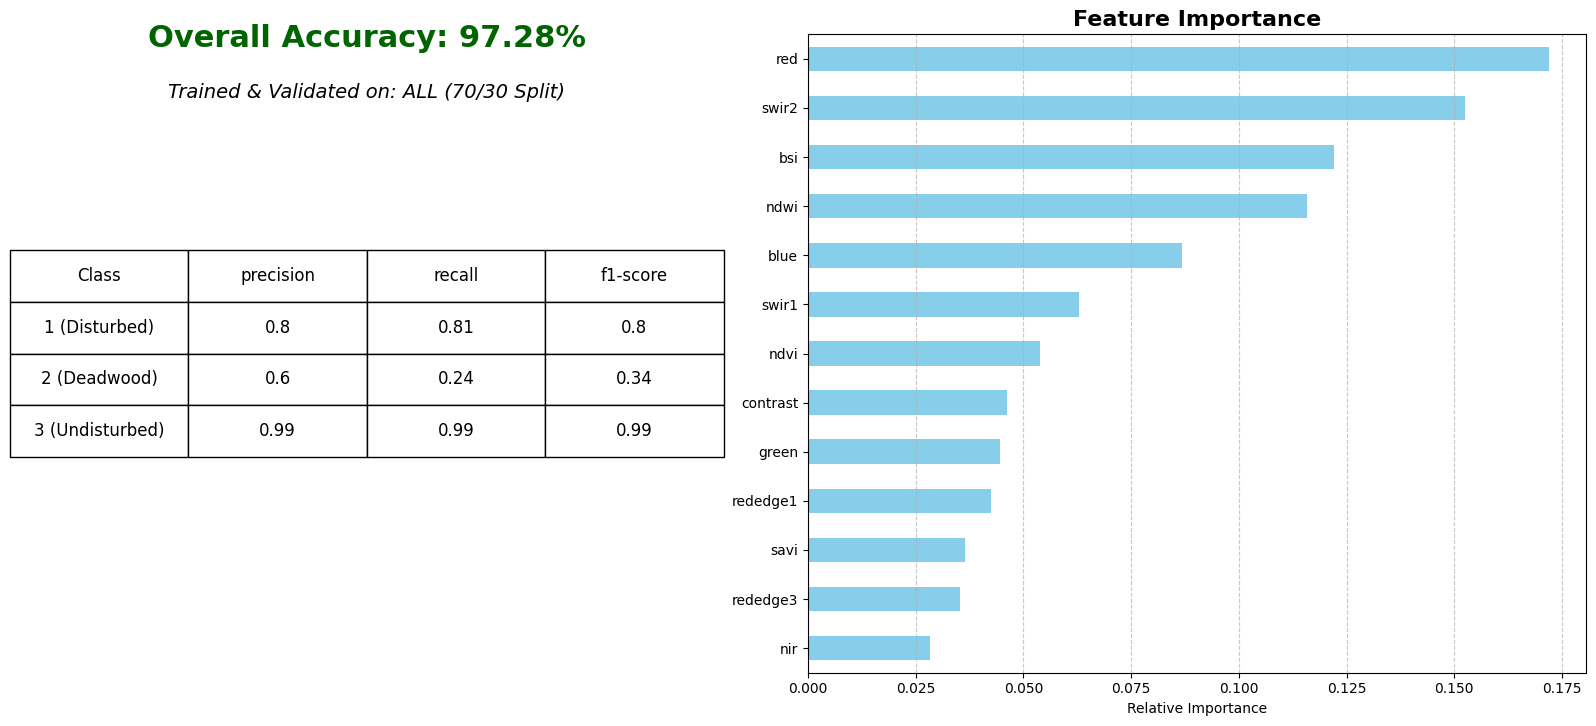

In [200]:
overall_acc = accuracy_score(forestclass_test, predictions)
report_dict = classification_report(forestclass_test, predictions, output_dict=True)

# Create the metrics table
report_df = pd.DataFrame(report_dict).iloc[:-1, :3].T
report_df.index = ['1 (Disturbed)', '2 (Deadwood)', '3 (Undisturbed)']
report_df = report_df.round(2).reset_index().rename(columns={'index': 'Class'})

# Prepare Feature Importance (using pred_train to ensure correct labels)
importances = pd.Series(rf.feature_importances_, index=pred_train.columns).sort_values(ascending=True)

# 2. Dynamic Info Line Logic
if REGION_TRAIN_MODE == REGION_VAL_MODE:
    data_info = f"Trained & Validated on: {REGION_TRAIN_MODE} (70/30 Split)"
else:
    data_info = f"Trained on: {REGION_TRAIN_MODE} | Validated with: {REGION_VAL_MODE}"

# 3. Create Combined Figure
fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Left Side: Table & Accuracy Score ---
ax_table.axis('off')

# Big Overall Accuracy Score
ax_table.text(0.5, 0.98, f"Overall Accuracy: {overall_acc:.2%}",
              fontsize=22, fontweight='bold', ha='center', color='darkgreen')

# Dynamic Data Source Line
ax_table.text(0.5, 0.90, data_info,
              fontsize=14, fontstyle='italic', ha='center', color='black')

ax_table.set_title('', fontsize=14, pad=60)
the_table = ax_table.table(cellText=report_df.values,
                           colLabels=report_df.columns,
                           loc='center',
                           cellLoc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(12)
the_table.scale(1.1, 3)

importances.plot(kind='barh', color='skyblue', ax=ax_plot)
ax_plot.set_title('Feature Importance', fontsize=16, fontweight='bold')
ax_plot.set_xlabel('Relative Importance')
ax_plot.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [201]:
#joblib.dump(rf, r"C:\Users\miles\OneDrive\Dokumente\ROOT\models\rf_s22_s22\rf_s22_s22.joblib")